In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from torchviz import make_dot

In [2]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

In [3]:
model

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2SdpaAttention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [4]:
sequence_length = model.config.n_positions  # Get the actual sequence length of the model
vocab_size = tokenizer.vocab_size  # Get the vocabulary size

print(f"Sequence Length: {sequence_length}")
print(f"Vocabulary Size: {vocab_size}")

Sequence Length: 1024
Vocabulary Size: 50257


In [5]:
embedding_matrix_shape = model.transformer.wte.weight.shape
print(f"Embedding Matrix Dimensions: {embedding_matrix_shape}")

Embedding Matrix Dimensions: torch.Size([50257, 768])


In [6]:
prompt = "The quick brown fox jumps over"
inputs = tokenizer(prompt, return_tensors="pt")
inputs

{'input_ids': tensor([[  464,  2068,  7586, 21831, 18045,   625]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1]])}

In [ ]:
with torch.no_grad():
    outputs = model(**inputs)

logits = outputs.logits
print(f"Logits Shape: {logits.shape}")

#explanation about output
# The output logits shape is (batch_size, sequence_length, vocab_size)
# The sequence length is the number of tokens in the input prompt
# In simpler terms for each token in input prompt,the model gives a score for each token in vocabulary saying what is the probability of that token being the next token

Logits Shape: torch.Size([1, 6, 50257])


In [ ]:
# now since we are only concerned about the next token of last  token in the input prompt,we only gonna consider the scores for last token in the input prompt\
last_logits = logits[:, -1, :] # extract scores for last token
next_token_id = last_logits.argmax(dim=-1) # get the token id with highest score
# The way to consider only the predicted token having max score is called greedy sampling
# In general ,we use sampling techniques to sample the next token from the distribution of scores
next_token_id 

tensor([262])

In [ ]:
tokenizer.decode(next_token_id) #decoding the token id to get the word

' the'

In [12]:
# to generate the next token,we append the predicted token to the input prompt and repeat the process

next_inputs = {
    "input_ids": torch.cat(
        [inputs["input_ids"], next_token_id.reshape((1, 1))],
        dim=1
    ),
    "attention_mask": torch.cat(
        [inputs["attention_mask"], torch.tensor([[1]])],
        dim=1
    ),
}

In [13]:
print(next_inputs["input_ids"],
      next_inputs["input_ids"].shape)
print(next_inputs["attention_mask"],
      next_inputs["attention_mask"].shape)

tensor([[  464,  2068,  7586, 21831, 18045,   625,   262]]) torch.Size([1, 7])
tensor([[1, 1, 1, 1, 1, 1, 1]]) torch.Size([1, 7])


## 3. Prefill and decode: optimizing token generation over multiple steps

In [14]:
def generate_token(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id



In [15]:
generated_tokens = []
next_inputs = inputs
durations_s = []
for _ in range(10):
    t0 = time.time()
    next_token_id = generate_token(next_inputs)
    durations_s += [time.time() - t0]
    
    next_inputs = {
        "input_ids": torch.cat(
            [next_inputs["input_ids"], next_token_id.reshape((1, 1))],
            dim=1),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])],
            dim=1),
    }
    
    next_token = tokenizer.decode(next_token_id)
    generated_tokens.append(next_token)

print(f"{sum(durations_s)} s")
print(generated_tokens)

0.593937873840332 s
[' the', ' fence', ' and', ' runs', ' into', ' the', ' bushes', '.', '\n', '\n']


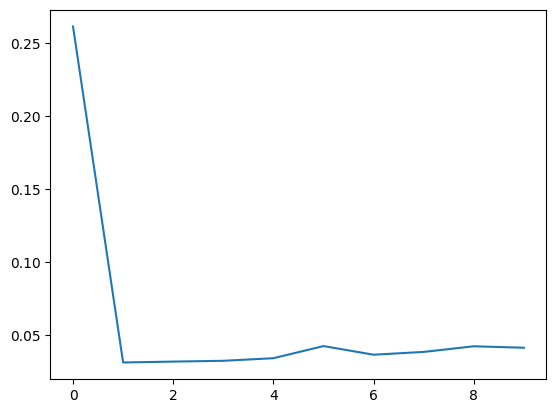

In [17]:
# Plot token generation time
# The x-axis here is the token number
# The y-axis is the time to generate a token in millisenconds (ms)
plt.plot(durations_s)
plt.show()

## Optmization Technique (KV caching)

During attention mechanims,for each token we generate key and value vectors which is dot product of key weights and embedding of the input token. These vectors are used to compute the attention scores for the next token in the sequence.and all the vectors are concatenated to form a single tensor. This tensor is then used to compute the attention scores for the next token in the sequence.

This process is repeated for each token in the sequence, and the key and value vectors are updated at each step. This means that the model has to recompute the key and value vectors for all previous tokens in the sequence, which can be computationally expensive.

To optimize this process, we can use a technique called KV caching. This technique allows us to cache the key and value vectors for each token in the sequence, so that we don't have to recompute them for each subsequent token. Instead, we can simply retrieve the cached vectors from memory, which can significantly speed up the decoding process.

In [18]:
def generate_token_with_past(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id, outputs.past_key_values

In [19]:
generated_tokens = []
next_inputs = inputs
durations_cached_s = []
for _ in range(10):
    t0 = time.time()
    next_token_id, past_key_values = \
        generate_token_with_past(next_inputs)
    durations_cached_s += [time.time() - t0]
    
    next_inputs = {
        "input_ids": next_token_id.reshape((1, 1)),
        "attention_mask": torch.cat(
            [next_inputs["attention_mask"], torch.tensor([[1]])],
            dim=1),
        "past_key_values": past_key_values,
    }
    
    next_token = tokenizer.decode(next_token_id)
    generated_tokens.append(next_token)

print(f"{sum(durations_cached_s)} s")
print(generated_tokens)

0.42868924140930176 s
[' the', ' fence', ' and', ' runs', ' into', ' the', ' bushes', '.', '\n', '\n']


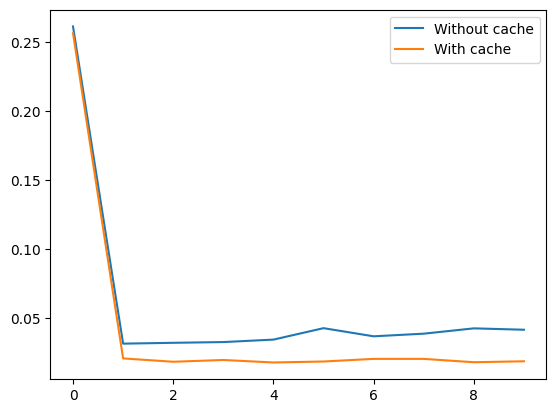

In [21]:
plt.plot(durations_s)
plt.plot(durations_cached_s)
# add legend
plt.legend(["Without cache", "With cache"])
plt.show()

## Optmizing Technique2 (Batch Decoding)
Batch decoding is a technique used in natural language processing (NLP) to generate multiple sequences of tokens in parallel, rather than one at a time. This can significantly speed up the decoding process, especially for large models and long sequences.
Here we have to consider two metrics:

1. **Throughput**: The number of tokens generated per second.
2. **Latency**: The time it takes to generate a single token.

There is always some trade-off between throughput and latency, and the optimal batch size will depend on the specific use case and the hardware being used.

In general, larger batch sizes will result in higher throughput, but may also increase latency. Conversely, smaller batch sizes will result in lower throughput, but may also decrease latency. The optimal batch size will depend on the specific use case and the hardware being used.


### Synchronous Batching


The batches will be given as input in following format:
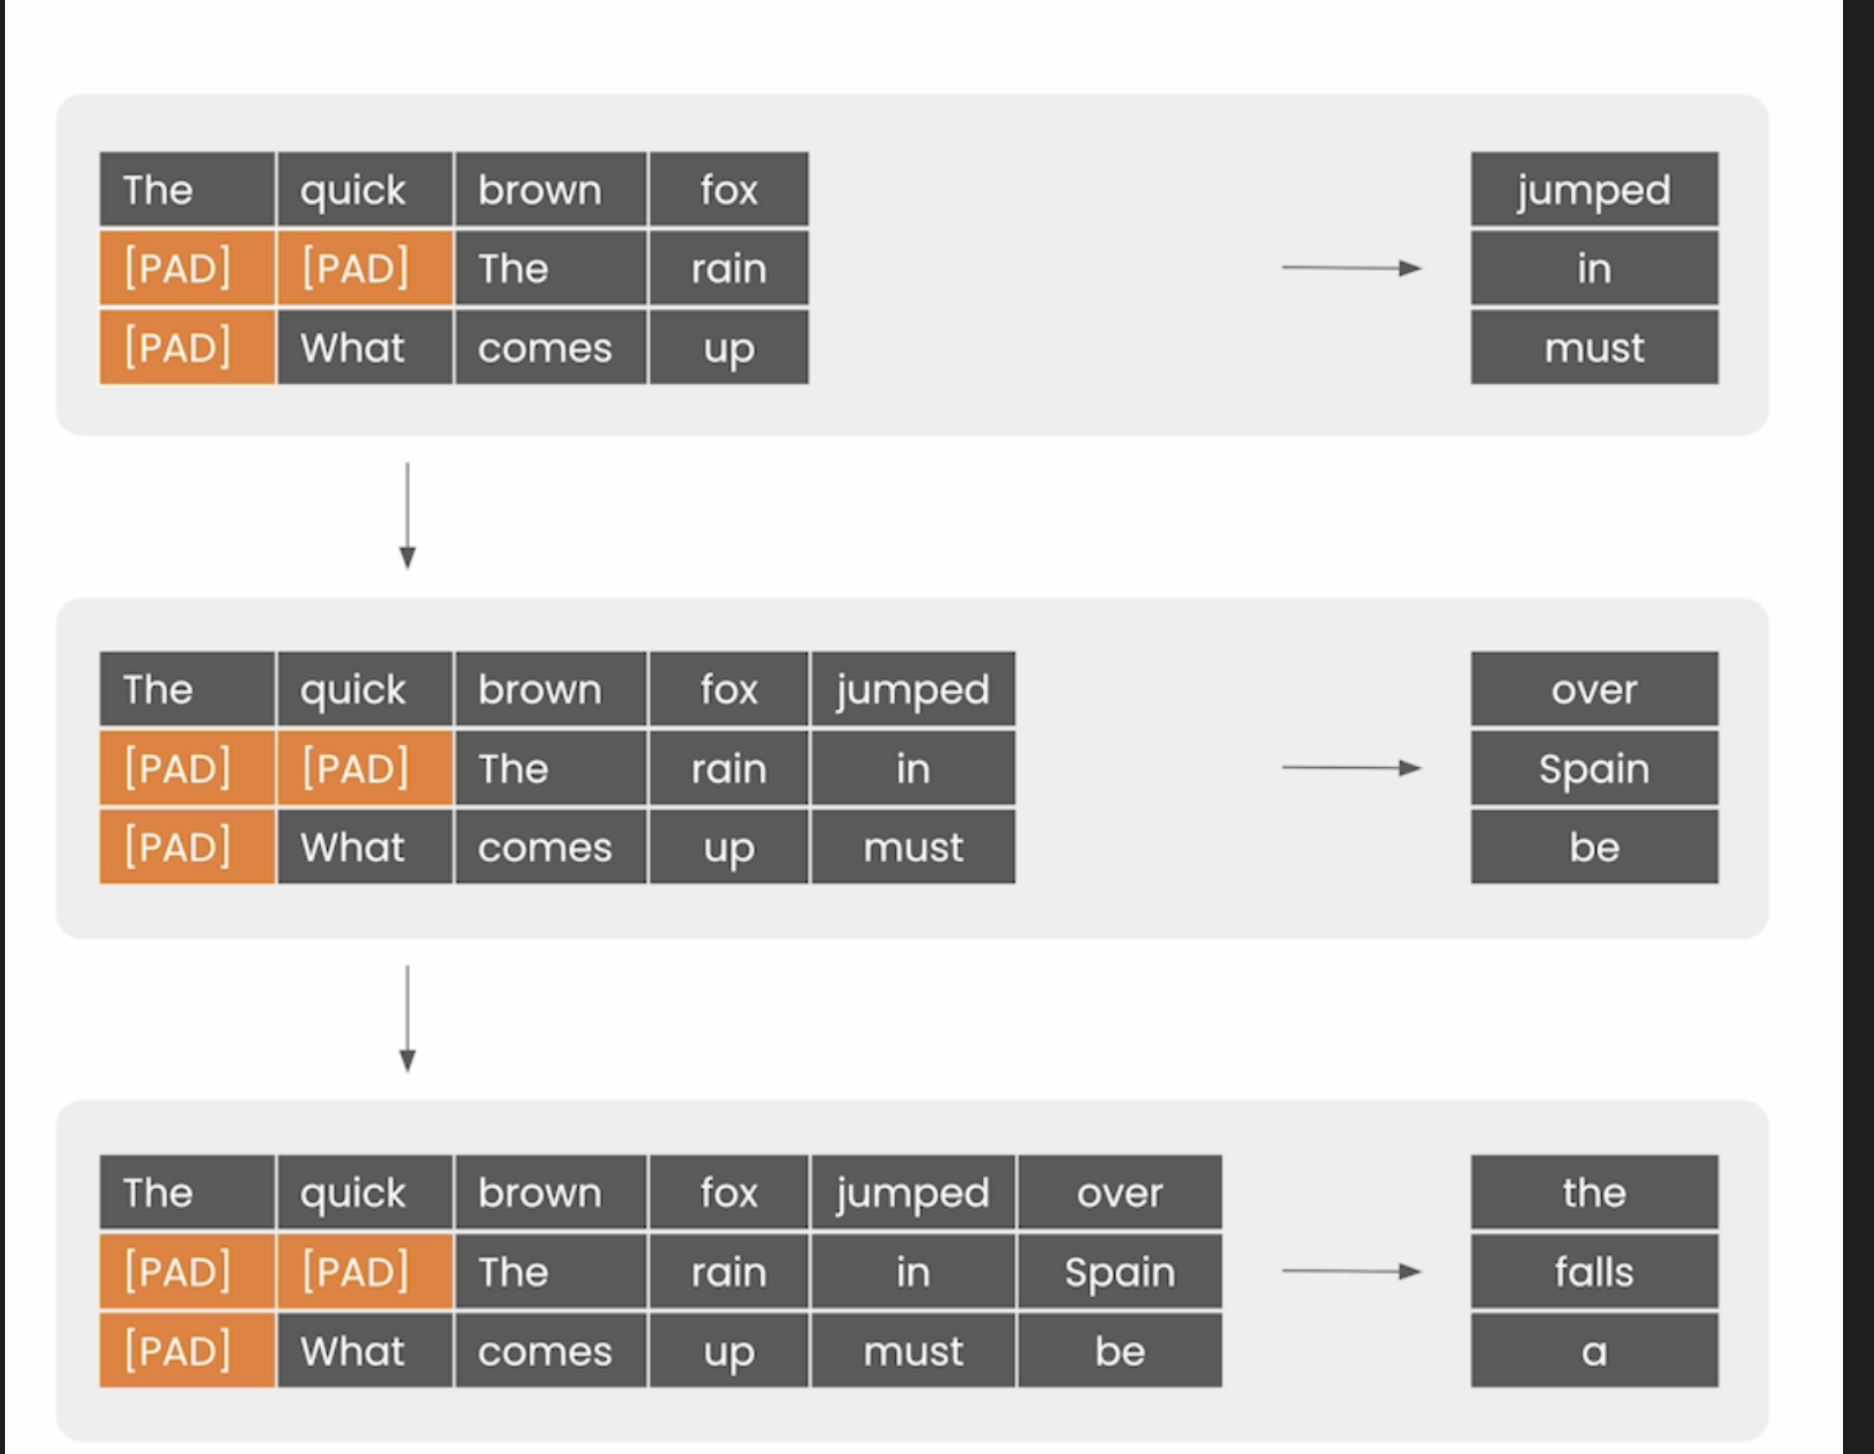

To ensure that input sequence are of same lenght,padding is used.In padding we add a special token(usualy a eos token) to the left of the input sequence to make it of same length as the longest sequence in the batch. This allows us to process multiple sequences in parallel, which can significantly speed up the decoding process.

In synchronoues batching, we process multiple sequences in parallel, but we still need to wait for all sequences to finish before we can move on to the next batch. This means that if one sequence takes longer to process than the others, it can slow down the entire batch.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import time
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

In [2]:
model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

In [3]:
prompt = "The quick brown fox jumped over the"
inputs = tokenizer(prompt, return_tensors="pt")


def generate_token_with_past(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[0, -1, :]
    next_token_id = last_logits.argmax()
    return next_token_id, outputs.past_key_values


def generate(inputs, max_tokens):
    generated_tokens = []
    next_inputs = inputs
    for _ in range(max_tokens):
        next_token_id, past_key_values = \
        generate_token_with_past(next_inputs)
        next_inputs = {
            "input_ids": next_token_id.reshape((1, 1)),
            "attention_mask": torch.cat(
                [next_inputs["attention_mask"], torch.tensor([[1]])],
                dim=1
            ),
            "past_key_values": past_key_values,
        }

        next_token = tokenizer.decode(next_token_id)
        generated_tokens.append(next_token)
    return "".join(generated_tokens)


tokens = generate(inputs, max_tokens=10)
print(tokens)

 fence and ran to the other side of the fence


In [4]:
# Define PAD Token = EOS Token = 50256
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id

# pad on the left so we can append new tokens on the right
tokenizer.padding_side = "left"
tokenizer.truncation_side = "left"

In [5]:
# multiple prompts of varying lengths to send
# to the model at once
prompts = [
    "The quick brown fox jumped over the",
    "The rain in Spain falls",
    "What comes up must",
]

# note: padding=True ensures the padding token
# will be inserted into the tokenized tensors
inputs = tokenizer(prompts, padding=True, return_tensors="pt")

In [6]:
print("input_ids:", inputs["input_ids"])
print("shape:", inputs["input_ids"].shape)

input_ids: tensor([[  464,  2068,  7586, 21831, 11687,   625,   262],
        [50256, 50256,   464,  6290,   287,  8602,  8953],
        [50256, 50256, 50256,  2061,  2058,   510,  1276]])
shape: torch.Size([3, 7])


In [7]:
print("attention_mask:", inputs["attention_mask"])
print("shape:", inputs["attention_mask"].shape)

attention_mask: tensor([[1, 1, 1, 1, 1, 1, 1],
        [0, 0, 1, 1, 1, 1, 1],
        [0, 0, 0, 1, 1, 1, 1]])
shape: torch.Size([3, 7])


In [17]:
# position_ids tell the transformer the ordinal position
# of each token in the input sequence
# for single input inference, this is just [0 .. n]
# for n tokens, but for batch inference,
# we need to 0 out the padding tokens at the start of the sequence
attention_mask = inputs["attention_mask"]
position_ids = attention_mask.long().cumsum(-1) - 1  
position_ids.masked_fill_(attention_mask == 0, 1)

tensor([[0, 1, 2, 3, 4, 5, 6],
        [1, 1, 0, 1, 2, 3, 4],
        [1, 1, 1, 0, 1, 2, 3]])

In [21]:
position_ids[:, -1].unsqueeze(-1)+1

tensor([[7],
        [5],
        [4]])

In [38]:
# same as before, but include the position_ids
with torch.no_grad():
    outputs = model(position_ids=position_ids, **inputs)
logits = outputs.logits
logits.shape

torch.Size([3, 7, 50257])

In [39]:
last_logits = logits[:, -1, :] 
next_token_ids = last_logits.argmax(dim=1) 
next_token_ids

tensor([13990,   319,   307])

In [ ]:
next_token_ids.reshape(-1, 1)  

In [40]:
next_tokens = tokenizer.batch_decode(next_token_ids)
next_tokens

[' fence', ' on', ' be']

### Let's put it all together!
 - Generate n tokens with past

In [24]:
def generate_batch_tokens_with_past(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[:, -1, :]
    next_token_ids = last_logits.argmax(dim=1)
    return next_token_ids, outputs.past_key_values

In [ ]:
def generate_batch(inputs, max_tokens):
    # create a list of tokens for every input in the batch
    generated_tokens = [
        [] for _ in range(inputs["input_ids"].shape[0])
    ]

    attention_mask = inputs["attention_mask"]
    position_ids = attention_mask.long().cumsum(-1) - 1
    position_ids.masked_fill_(attention_mask == 0, 1)

    next_inputs = {
        "position_ids": position_ids,
        **inputs
    }

    for _ in range(max_tokens):
        next_token_ids, past_key_values = \
            generate_batch_tokens_with_past(next_inputs)

        next_inputs = {
            "input_ids": next_token_ids.reshape((-1, 1)), # reshape to (batch_size, 1)
            "position_ids": next_inputs["position_ids"][:, -1].unsqueeze(-1) + 1, #giving the position ids of the new token only
            "attention_mask": torch.cat([
                next_inputs["attention_mask"],
                torch.ones((next_token_ids.shape[0], 1)),  
            ], dim=1),                                          # adding the attention mask for the new token
            "past_key_values": past_key_values,
        }

        next_tokens = tokenizer.batch_decode(next_token_ids)
        for i, token in enumerate(next_tokens):
            generated_tokens[i].append(token)
    return ["".join(tokens) for tokens in generated_tokens]

In [26]:
generated_tokens = generate_batch(inputs, max_tokens=10)

tensor([[7],
        [5],
        [4]])
tensor([[8],
        [6],
        [5]])
tensor([[9],
        [7],
        [6]])
tensor([[10],
        [ 8],
        [ 7]])
tensor([[11],
        [ 9],
        [ 8]])
tensor([[12],
        [10],
        [ 9]])
tensor([[13],
        [11],
        [10]])
tensor([[14],
        [12],
        [11]])
tensor([[15],
        [13],
        [12]])
tensor([[16],
        [14],
        [13]])


In [27]:
for prompt, generated in zip(prompts, generated_tokens):
    print(prompt, f"\x1b[31m{generated}\x1b[0m\n")

The quick brown fox jumped over the  fence and ran to the other side of the fence

The rain in Spain falls  on the first day of the month, and the

What comes up must  be a good idea.

"I think



### Throughput vs Latency

- Explore the effect of batching on latency (how long it takes to generate each token). 
- Observe the fundamental tradeoff that exists between throughput and latency.

In [28]:
# constants
max_tokens = 10

# observations
durations = []
throughputs = []
latencies = []

batch_sizes = [2**p for p in range(8)]
for batch_size in batch_sizes:
    print(f"bs= {batch_size}")

    # generate tokens for batch and record duration
    t0 = time.time()
    batch_prompts = [
        prompts[i % len(prompts)] for i in range(batch_size)
    ]
    inputs = tokenizer(
        batch_prompts, padding=True, return_tensors="pt"
    )
    generated_tokens = generate_batch(inputs, max_tokens=max_tokens)
    duration_s = time.time() - t0

    ntokens = batch_size * max_tokens
    throughput = ntokens / duration_s
    avg_latency = duration_s / max_tokens
    print("duration", duration_s)
    print("throughput", throughput)
    print("avg latency", avg_latency)    
    print()

    durations.append(duration_s)
    throughputs.append(throughput)
    latencies.append(avg_latency)

bs= 1
tensor([[7]])
tensor([[8]])
tensor([[9]])
tensor([[10]])
tensor([[11]])
tensor([[12]])
tensor([[13]])
tensor([[14]])
tensor([[15]])
tensor([[16]])
duration 0.36242198944091797
throughput 27.592144768661175
avg latency 0.036242198944091794

bs= 2
tensor([[7],
        [5]])
tensor([[8],
        [6]])
tensor([[9],
        [7]])
tensor([[10],
        [ 8]])
tensor([[11],
        [ 9]])
tensor([[12],
        [10]])
tensor([[13],
        [11]])
tensor([[14],
        [12]])
tensor([[15],
        [13]])
tensor([[16],
        [14]])
duration 0.6973891258239746
throughput 28.6783938254984
avg latency 0.06973891258239746

bs= 4
tensor([[7],
        [5],
        [4],
        [7]])
tensor([[8],
        [6],
        [5],
        [8]])
tensor([[9],
        [7],
        [6],
        [9]])
tensor([[10],
        [ 8],
        [ 7],
        [10]])
tensor([[11],
        [ 9],
        [ 8],
        [11]])
tensor([[12],
        [10],
        [ 9],
        [12]])
tensor([[13],
        [11],
        [10

In [29]:
def render_plot(x, y1, y2, x_label, y1_label, y2_label):
    # Create a figure and a set of subplots
    fig, ax1 = plt.subplots()

    # Plot the first line (throughput)
    color = 'tab:red'
    ax1.set_xlabel(x_label)
    ax1.set_ylabel(y1_label, color=color)
    line1, = ax1.plot(x, y1, color=color, label=y1_label)
    ax1.tick_params(axis='y', labelcolor=color)

    # Set the x-axis to be log-scaled
    ax1.set_xscale('log', base=2)

    # Instantiate a second axes that shares the same x-axis
    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel(y2_label, color=color)  # we already handled the x-label with ax1
    line2, = ax2.plot(x, y2, color=color, label=y2_label)
    ax2.tick_params(axis='y', labelcolor=color)

    # Add legend
    fig.legend(handles=[line1, line2], loc="upper left", bbox_to_anchor=(0.1, 0.9))

    plt.show()

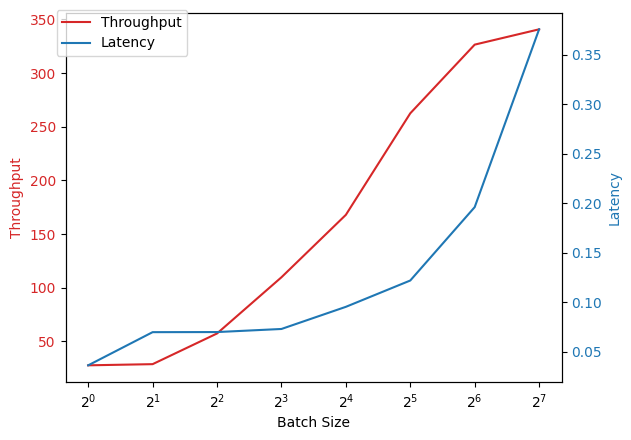

In [30]:
render_plot(
    batch_sizes,
    throughputs,
    latencies,
    "Batch Size",
    "Throughput",
    "Latency"
)

### Asynchronous Batching

In asynchonous batching,we do not wait for all the sequence to finish up before moving to the next batch. Instead, we process each sequence as it becomes available, which can significantly speed up the decoding process. This means that if one sequence takes longer to process than the others, it will not slow down the entire batch.

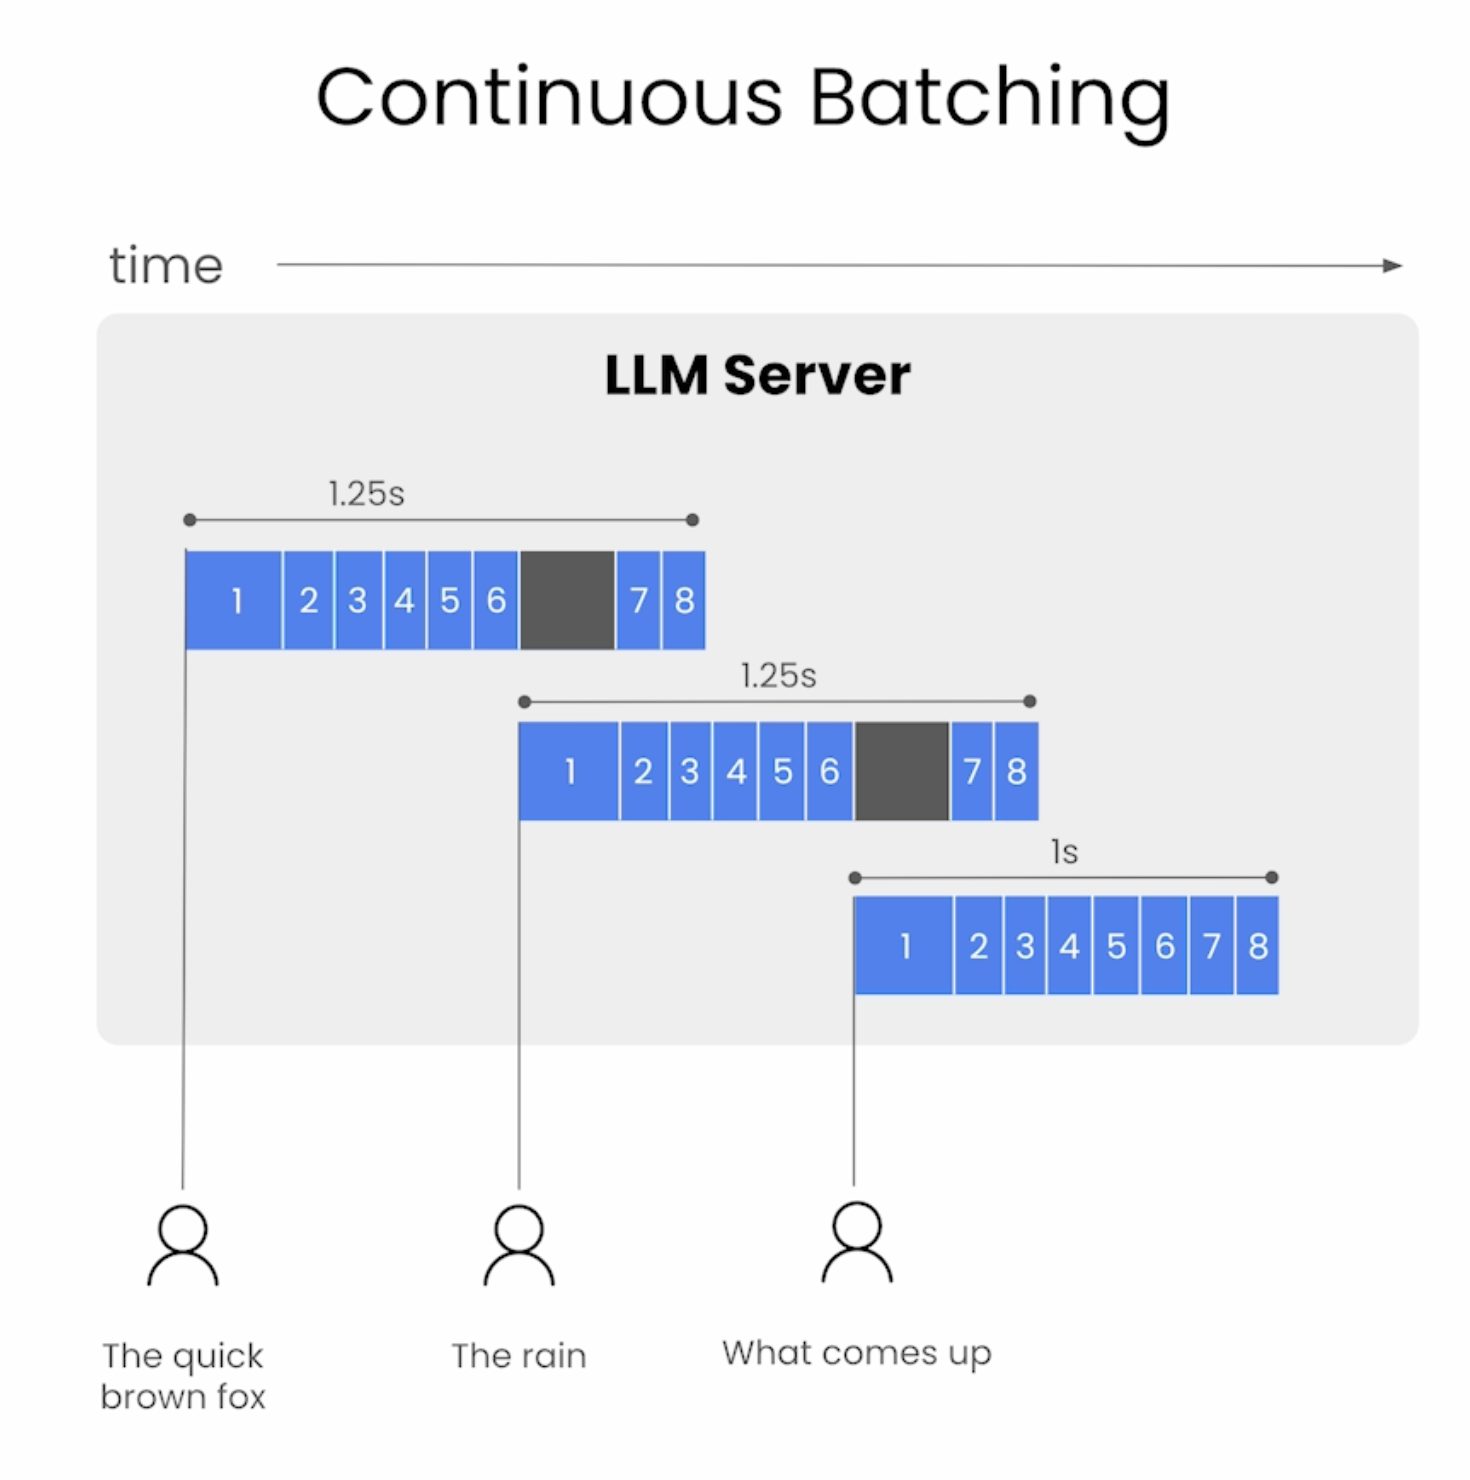

In [32]:
import copy
import matplotlib.pyplot as plt
import numpy as np
import random
import time
import torch
import torch.nn.functional as F
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)


# Define PAD Token = EOS Token = 50256
tokenizer.pad_token = tokenizer.eos_token
model.config.pad_token_id = model.config.eos_token_id

# pad on the left so we can append new tokens on the right
tokenizer.padding_side = "left"
tokenizer.truncation_side = "left"


# multiple prompts of varying lengths to send to the model at once
prompts = [
    "The quick brown fox jumped over the",
    "The rain in Spain falls",
    "What comes up must",
]

# note: padding=True ensures the padding token will be inserted into the tokenized tensors
inputs = tokenizer(prompts, padding=True, return_tensors="pt")

In [ ]:
def get_next_inputs(batch, next_token_ids, past_key_values, next_tokens):
    return {
        # '-1' here means the remaining elements for this dim
        "input_ids": next_token_ids.reshape((-1, 1)),
        # increment last, discard the rest
        "position_ids": batch["position_ids"][:, -1].unsqueeze(-1) + 1,
        # concatenate vector of 1's with shape [batch_size]
        "attention_mask": torch.cat([
            batch["attention_mask"],
            torch.ones((next_token_ids.shape[0], 1)),  
        ], dim=1),
        "past_key_values": past_key_values,
        "responses": [
            r1 + r2 for r1, r2 
            in zip(batch["responses"], next_tokens)],
        "tokens_remaining": [
            v - 1 for v in batch["tokens_remaining"]],
    }


def init_batch(requests):
    prompts = [r[0] for r in requests]
    inputs = tokenizer(prompts, padding=True, return_tensors="pt")
    
    attention_mask = inputs["attention_mask"]
    position_ids = attention_mask.long().cumsum(-1) - 1
    position_ids.masked_fill_(attention_mask == 0, 1)
    
    return {
        "position_ids": position_ids,
        "responses": copy.copy(prompts),
        "tokens_remaining": [r[1] for r in requests],
        **inputs
    }


def generate_next_token(batch):
    inputs = copy.copy(batch)
    inputs.pop("responses")
    inputs.pop("tokens_remaining")
    
    next_token_ids, past_key_values = \
        generate_batch_tokens_with_past(inputs)
    next_tokens = tokenizer.batch_decode(next_token_ids)
    return get_next_inputs(
        batch, next_token_ids, past_key_values, next_tokens)


def merge_batches(batch1, batch2):
    # first find the max sequence length of the two batches
    # this can be obtained from the second dimension 
    # of the attention mask
    attn_mask1 = batch1["attention_mask"]
    attn_mask2 = batch2["attention_mask"]
    max_seq_len = max(attn_mask1.shape[1], attn_mask2.shape[1])
    
    # pad each mask (on the left) to the max sequence length
    # attention mask uses 0 for padding
    padding1 = max_seq_len - attn_mask1.shape[1]
    padding2 = max_seq_len - attn_mask2.shape[1]
    attn_mask1 = F.pad(attn_mask1, (padding1, 0), "constant", 0)
    attn_mask2 = F.pad(attn_mask2, (padding2, 0), "constant", 0)
    
    # because we only append batches post decoding, 
    # we don't need to pad input_ids
    # or position_ids. these are always length 1 
    # in the sequence dimension
    # however, we do need to pad the 
    # past_key_values, which have shape:
    # [batch_size, num_heads, sequence_length, head_dim]
    past_kv1 = batch1["past_key_values"]
    past_kv2 = batch2["past_key_values"]
    
    padded_kv1 = []
    for i in range(len(past_kv1)):
        k, v = past_kv1[i]
        k = F.pad(k, (0, 0, padding1, 0), "constant", 0)
        v = F.pad(v, (0, 0, padding1, 0), "constant", 0)     
        padded_kv1.append((k, v))
    
    padded_kv2 = []
    for i in range(len(past_kv2)):
        k, v = past_kv2[i]
        k = F.pad(k, (0, 0, padding2, 0), "constant", 0)
        v = F.pad(v, (0, 0, padding2, 0), "constant", 0)     
        padded_kv2.append((k, v))
        
    # now that everything has been padded to have
    # consistent shapes, let's merge
    input_ids = torch.concat(
        [batch1["input_ids"], batch2["input_ids"]], dim=0)
    position_ids = torch.concat(
        [batch1["position_ids"], batch2["position_ids"]], dim=0) 
    attn_mask = torch.concat([attn_mask1, attn_mask2], dim=0)
    
    past_kv = []
    for i in range(len(padded_kv1)):
        k1, v1 = padded_kv1[i]
        k2, v2 = padded_kv2[i]
        k = torch.concat([k1, k2], dim=0)
        v = torch.concat([v1, v2], dim=0)
        past_kv.append((k, v))
    
    return {
        "input_ids": input_ids,
        "position_ids": position_ids,
        "attention_mask": attn_mask,
        "past_key_values": past_kv,
        "responses": batch1["responses"] + batch2["responses"],
        "tokens_remaining": batch1["tokens_remaining"] + batch2["tokens_remaining"],
    }


def filter_batch(batch):
    # mark all rows with 0 tokens remaining for removal
    remove_indices = []
    for i, tokens_remaining in enumerate(batch["tokens_remaining"]):
        if tokens_remaining <= 0:
            remove_indices.append(i)
    
    # first, define a mask used to subselect the indices to keep
    # from each tensor, given the indices to remove
    batch_size = batch["input_ids"].size(0)
    mask = torch.ones(batch_size, dtype=torch.bool)
    mask[remove_indices] = False

    # index into the tensors using the mask to remove rows
    input_ids = batch["input_ids"][mask]
    position_ids = batch["position_ids"][mask]
    attention_mask = batch["attention_mask"][mask]
    responses = [
        r 
        for i, r in enumerate(batch["responses"])
        if i not in remove_indices
    ]
    tokens_remaining = [
        v 
        for i, v in enumerate(batch["tokens_remaining"])
        if i not in remove_indices
    ]

    past_key_values = batch["past_key_values"]
    new_past_key_values = []
    for i in range(len(past_key_values)):
        k, v = past_key_values[i]
        k = k[mask]
        v = v[mask]
        new_past_key_values.append((k, v))
    past_key_values = new_past_key_values
    
    if input_ids.size(0) > 0:
        # next, as an optimization to avoid wasting 
        # compute cycles on padding tokens,
        # we will left truncate the attention_mask 
        # and past_key_values to the longest
        # remaining sequence length
        # we obtain the longest sequence length by 
        # looking for the min first non-zero index
        # of the attention mask
        # cumprod ensures we stop accumulating when we see a 1
        zero_mask = attention_mask == 0
        cumprod = zero_mask.cumprod(dim=1)  
        leading_zeros_count = cumprod.sum(dim=1)
        min_leading_zeros = torch.min(leading_zeros_count)
        truncation_offset = min_leading_zeros.item()

        # do the trunction
        attention_mask = attention_mask[:, truncation_offset:]
        past_key_values = past_key_values
        new_past_key_values = []
        for i in range(len(past_key_values)):
            k, v = past_key_values[i]
            k = k[:, :, truncation_offset:, :]
            v = v[:, :, truncation_offset:, :]
            new_past_key_values.append((k, v))
        past_key_values = new_past_key_values
    
    # return the new batch
    return {
        "input_ids": input_ids,
        "position_ids": position_ids,
        "attention_mask": attention_mask,
        "past_key_values": past_key_values,
        "responses": responses,
        "tokens_remaining": tokens_remaining,
    }, remove_indices


def generate_batch_tokens_with_past(inputs):
    with torch.no_grad():
        outputs = model(**inputs)

    logits = outputs.logits
    last_logits = logits[:, -1, :]
    next_token_ids = last_logits.argmax(dim=1)
    return next_token_ids, outputs.past_key_values

In [ ]:
# seed the random number generator so our results are deterministic
random.seed(42)

# constants
queue_size = 32
batch_size = 8

# requests waiting to be processed
# this time requests are tuples (prompt, max_tokens)
request_queue = [
    (prompts[0], 100 if i % batch_size == 0 else 10)
    for i in range(queue_size)
]

t0 = time.time()
with tqdm(total=len(request_queue), desc=f"bs={batch_size}") as pbar:
    # first, let's seed the initial cached_batch
    # with the first `batch_size` inputs
    # and run the initial prefill step
    batch = init_batch(request_queue[:batch_size])
    cached_batch = generate_next_token(batch)
    request_queue = request_queue[batch_size:]

    # continue until both the request queue is 
    # fully drained and every input
    # within the cached_batch has completed generation
    while (
        len(request_queue) > 0 or
        cached_batch["input_ids"].size(0) > 0
    ):
        batch_capacity = (
            batch_size - cached_batch["input_ids"].size(0)
        )
        if batch_capacity > 0 and len(request_queue) > 0:
            # prefill
            new_batch = init_batch(request_queue[:batch_capacity])
            new_batch = generate_next_token(new_batch)
            request_queue = request_queue[batch_capacity:]

            # merge
            cached_batch = merge_batches(cached_batch, new_batch)

        # decode
        cached_batch = generate_next_token(cached_batch)

        # remove any inputs that have finished generation
        cached_batch, removed_indices = filter_batch(cached_batch)
        pbar.update(len(removed_indices))

duration_s = time.time() - t0
print("duration", duration_s)